In [1]:

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


In [23]:
ql = 20
ol = 30
system = fluxonium_oscillator_system(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = ql,
    osc_level = ol,
    kappa = 0.0005,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(25) ],
    computaional_states = '1,2',
    w_d = 7.16475
    )

tot_time =733 + 20
tlist = np.linspace(0, tot_time, tot_time)


# 1 load result, truncate to 2-level

In [ ]:
with open('../pickles/mesolve_temp_kappa1em3.pkl', 'rb') as file:
    results1 = pickle.load(file)

with open('../pickles/mesolve_temp_kappa5em4.pkl', 'rb') as file:
    results2 = pickle.load(file)


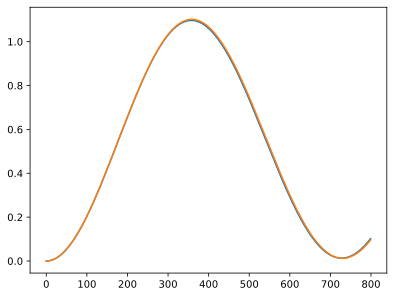

In [25]:
plt.plot(results1[0].expect[0],color = 'red')
plt.plot(results1[1].expect[0],color = 'red')
plt.plot(results2[0].expect[0],color = 'blue')
plt.plot(results2[1].expect[0],color = 'blue')

In [18]:
interactive_heatmap(results1[0], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=799), Output(…

In [12]:
for result in [results1[0],results1[1],results2[0],results2[1]]:
    result.twolevel_states = [dressed_to_2_level_dm(state, 
                                                    system.product_to_dressed, 
                                                    system.qubit_level,
                                                    system.osc_level,
                                                    system.computational_0,
                                                    system.computational_1,
                                                    products_to_keep=None)
                               for state in tqdm(result.states, desc=f"Processing states with {dressed_to_2_level_dm.__name__}")]
    

In [ ]:
results = results1

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)


states_ideal  = [(zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(tot_time):
    dms = [result.twolevel_states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])


plt.plot(results[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

In [ ]:
results = results2

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)


states_ideal  = [(zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(tot_time):
    dms = [result.twolevel_states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])


plt.plot(results[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")